# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

# Data Validation
This dataset has 12,500 rows truncated from 541,909 rows, 9 columns. I have validated all variables and I have not made any changes after validation. All the columns are just as described in the data dictionary: 

- InvoiceNo: 18532 unique identifier for each invoice, where one invoice may include multiple products. Checked for missing values and duplicates.
- StockCode: 3665 unique code assigned to each product sold by the retailer checked for missing or invalid values.
- Description: 3877 textual name describing the product. Checked for missing values.
- Quantity: 301 units purchased per product in a transaction. Identified zero or negative values.
- InvoiceDate: Date and time when the transaction occurred. Converted to datetime format.
- UnitPrice: Price of a single unit of a product.
- CustomerID: 4338 unique identifier for each customer. Checked missing values.
- Country: 37 countries where the customer is located. Checked consistency of country names.


In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [9]:
SELECT *
FROM "online_retail.csv"

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


In [30]:
df.dropna(subset=['StockCode', 'Description', 'CustomerID'], inplace=True)

In [42]:
df.drop_duplicates('InvoiceNo')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom
25,536369,21756,BATH BUILDING BLOCK WORD,3,2010-12-01 08:35:00,5.95,13047.0,United Kingdom
...,...,...,...,...,...,...,...,...
541865,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom
541869,581585,22481,BLACK TEA TOWEL CLASSIC DESIGN,12,2011-12-09 12:31:00,0.39,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom


In [31]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Exploratory Analysis
I have investigated the target variable and features of customer purchasing behavior, and the relationship between target variable and features. After the analysis, I decided tp apply the following changes to enable modeling :
- Distribution of Quantity
- Distribution of Unit Price

## Distribution of Quantity
Most transactions involve small quantities, indicating retail rather than wholesale behavior.

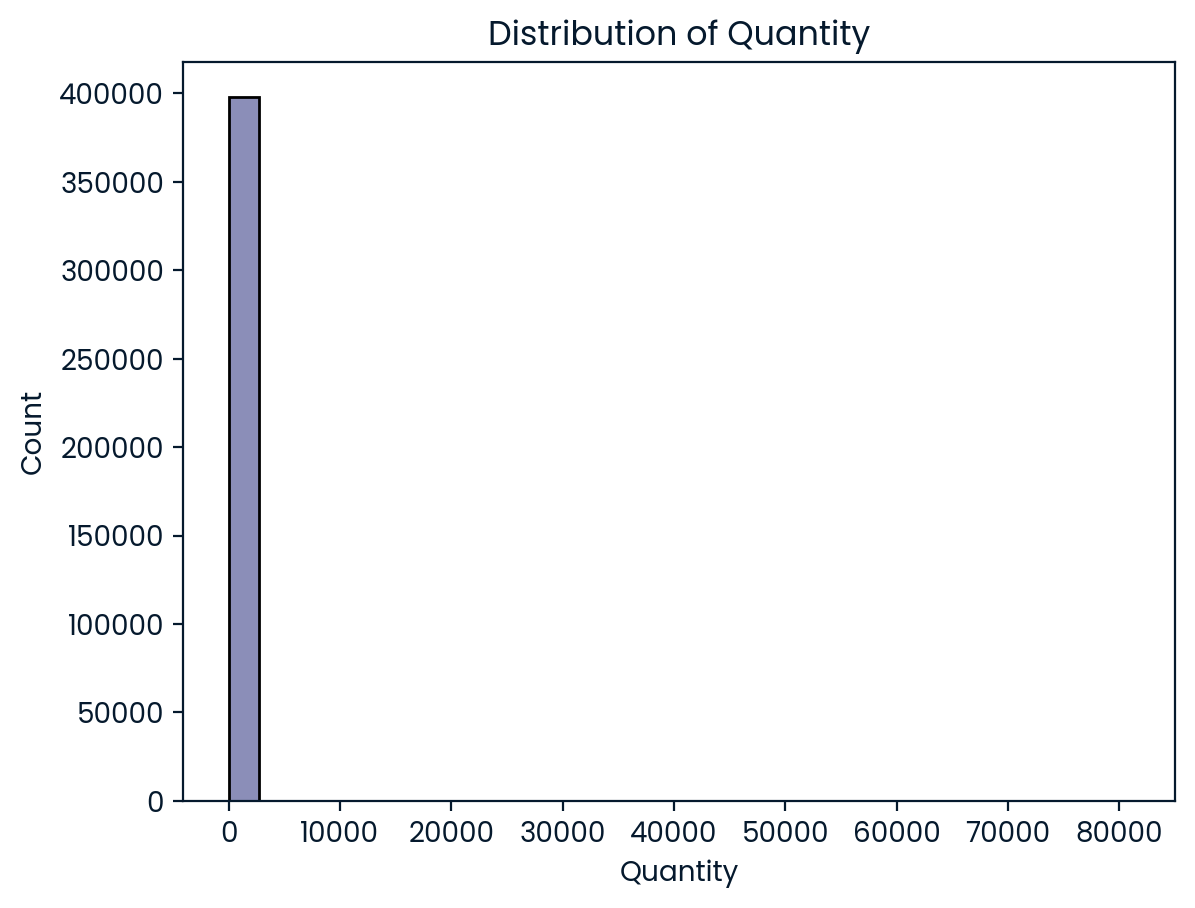

In [43]:
plt.figure()
sns.histplot(df['Quantity'], bins=30)
plt.title("Distribution of Quantity")
plt.show()

## Distribution of UnitPrice
Unit prices are right-skewed, with most products priced low and few expensive items

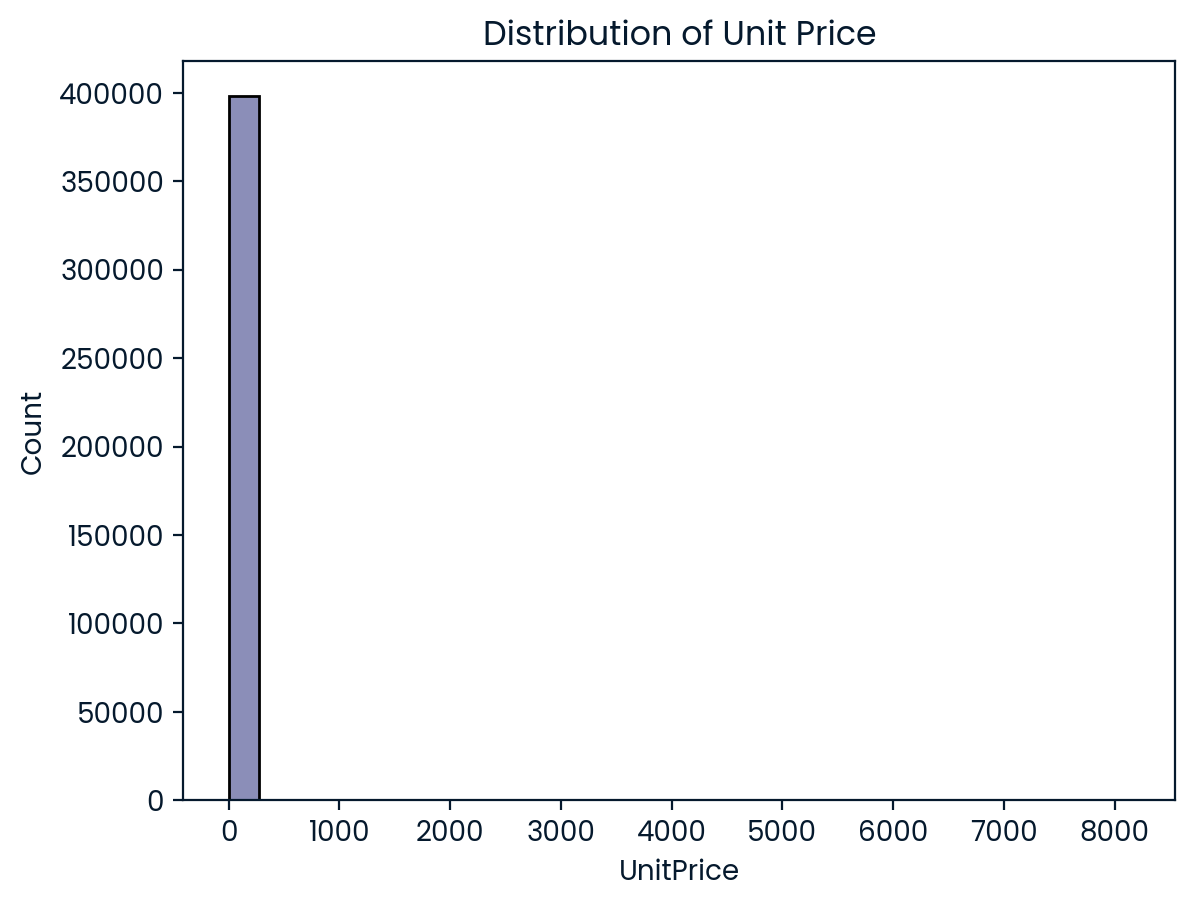

In [44]:
plt.figure()
sns.histplot(df['UnitPrice'], bins=30)
plt.title("Distribution of Unit Price")
plt.show()

## Numeric Variables
Basically no linear relationship between UnitPrice and Quantity. So, knowing the price doesn’t tell anything about how many units were bought.

[Text(0.5, 1.0, 'The Correlation Heatmap between Numeric Variavles')]

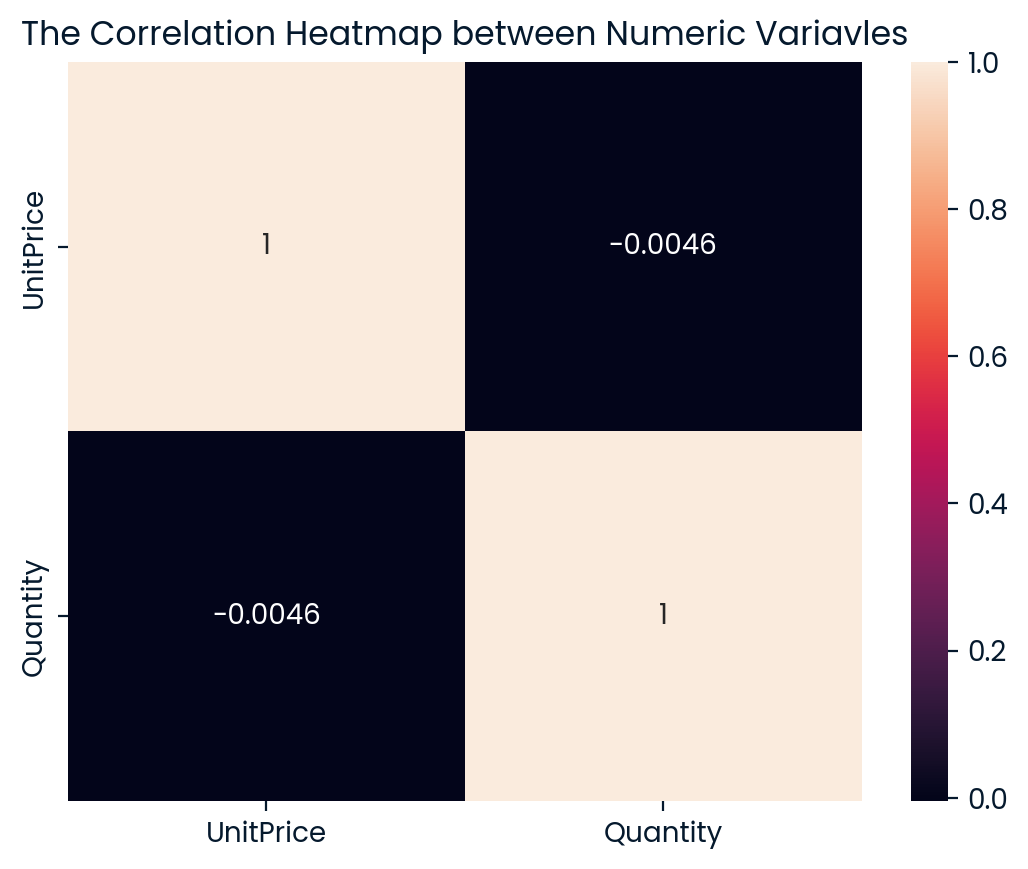

In [45]:
numeric = df[['UnitPrice', 'Quantity']]
sns.heatmap(numeric.corr(),annot=True).set(title='The Correlation Heatmap between Numeric Variavles')

# Quantity vs TotalPrice
- Higher quantities generally lead to higher revenue
- Extreme values suggest bulk purchases that significantly impact total sales

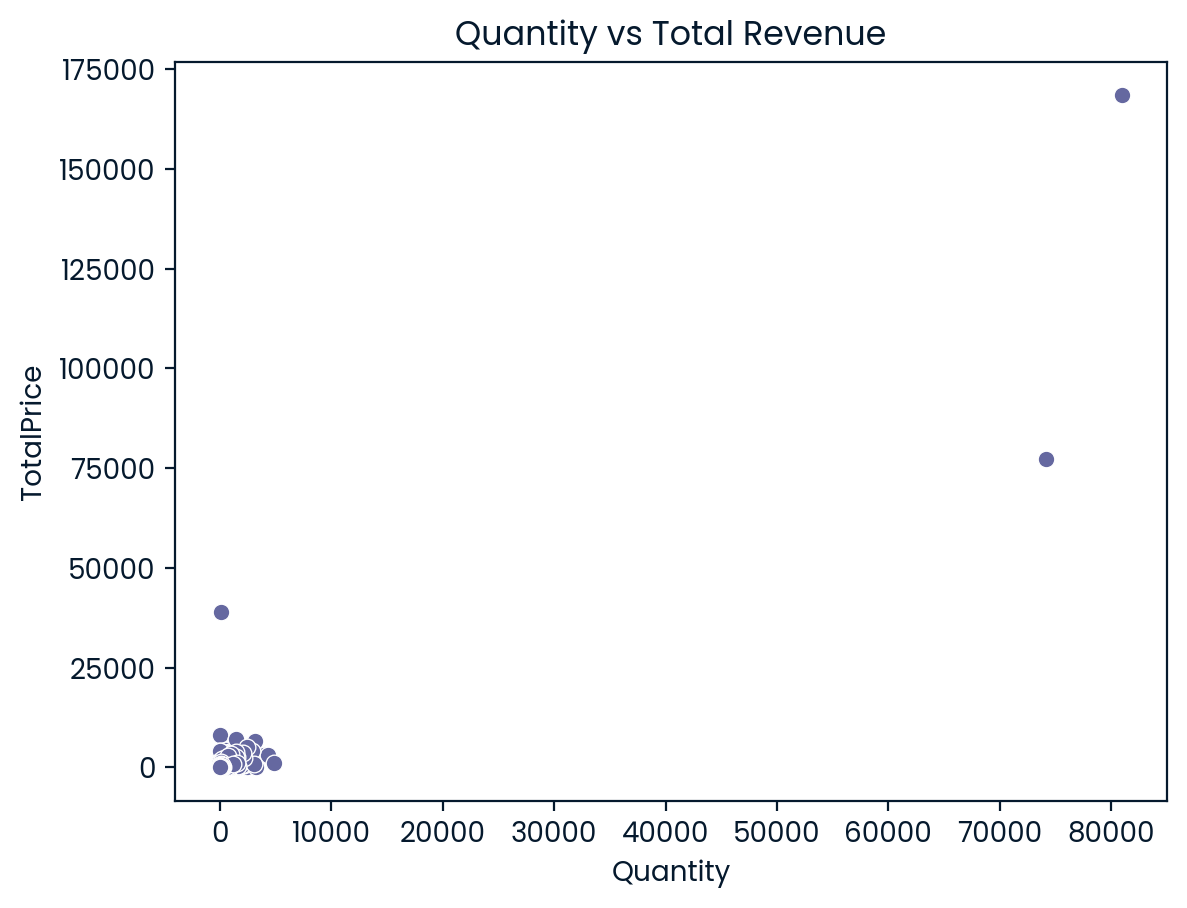

In [47]:
plt.figure()
sns.scatterplot(x='Quantity', y='TotalPrice', data=df)
plt.title("Quantity vs Total Revenue")
plt.show()

## Model Development

- Problem Type
This is a regression problem since we aim to predict a continuous target variable (`TotalPrice`).

### Models Selected
- Baseline Model: Linear Regression (simple and interpretable)
- Comparison Model: Random Forest Regressor (captures non-linear relationships)


In [79]:
features = df[['Quantity', 'UnitPrice']]
target = df['TotalPrice']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42
)

Baseline Model – Linear Regression

In [80]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [81]:
y_pred_lr = lr_model.predict(X_test)

print('Linear Regression Score r2_score: ',r2_score(y_test,y_pred_lr))
print('Linear Regression Root Mean Squared Error: ',  np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression Score r2_score:  0.8463479278316355
Linear Regression Root Mean Squared Error:  224.6022215979835


Finding the feature importance

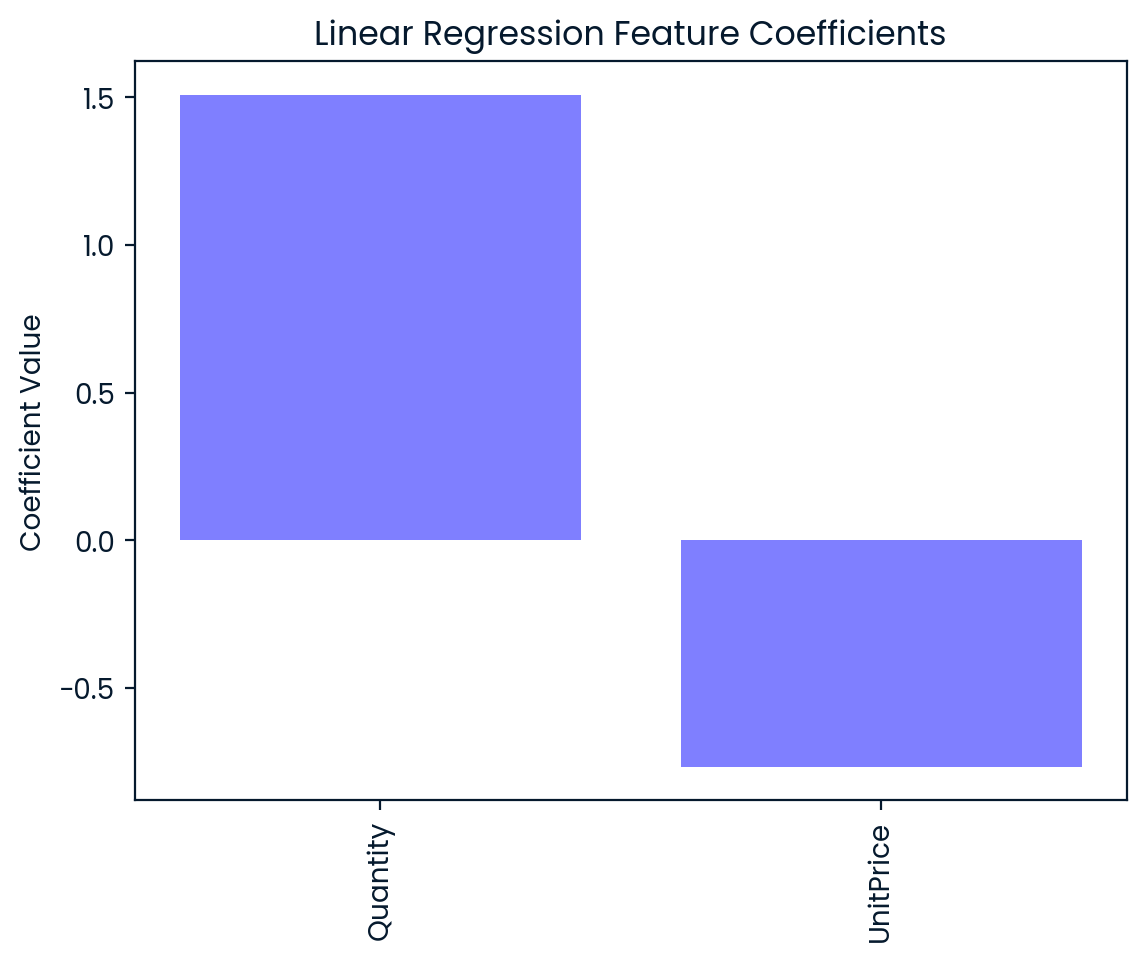

In [83]:
# Create dictionary of feature names to their coefficients
resultdict = {col: coef for col, coef in zip(X_train.columns, lr_model.coef_)}

import matplotlib.pyplot as plt

plt.bar(resultdict.keys(), resultdict.values(), alpha=0.5, color='blue')
plt.xticks(rotation='vertical')
plt.ylabel('Coefficient Value')
plt.title('Linear Regression Feature Coefficients')
plt.show()


Comparison Model – Random Forest

In [43]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [45]:
rf_2 = rf.score(X_test, y_test)
print("Random Forest Regressor R-squared: {}".format(rf_2))

r_mse = mean_squared_error(y_pred_rf, y_test)
r_rmse = np.sqrt(r_mse)
print("Random Forest Regressor RMSE: {}".format(r_rmse))

Random Forest Regressor R-squared: 0.533156962519244
Random Forest Regressor RMSE: 391.49866001029216


Finding the feature importance

Feature Importances: [0.74753366 0.25246634]


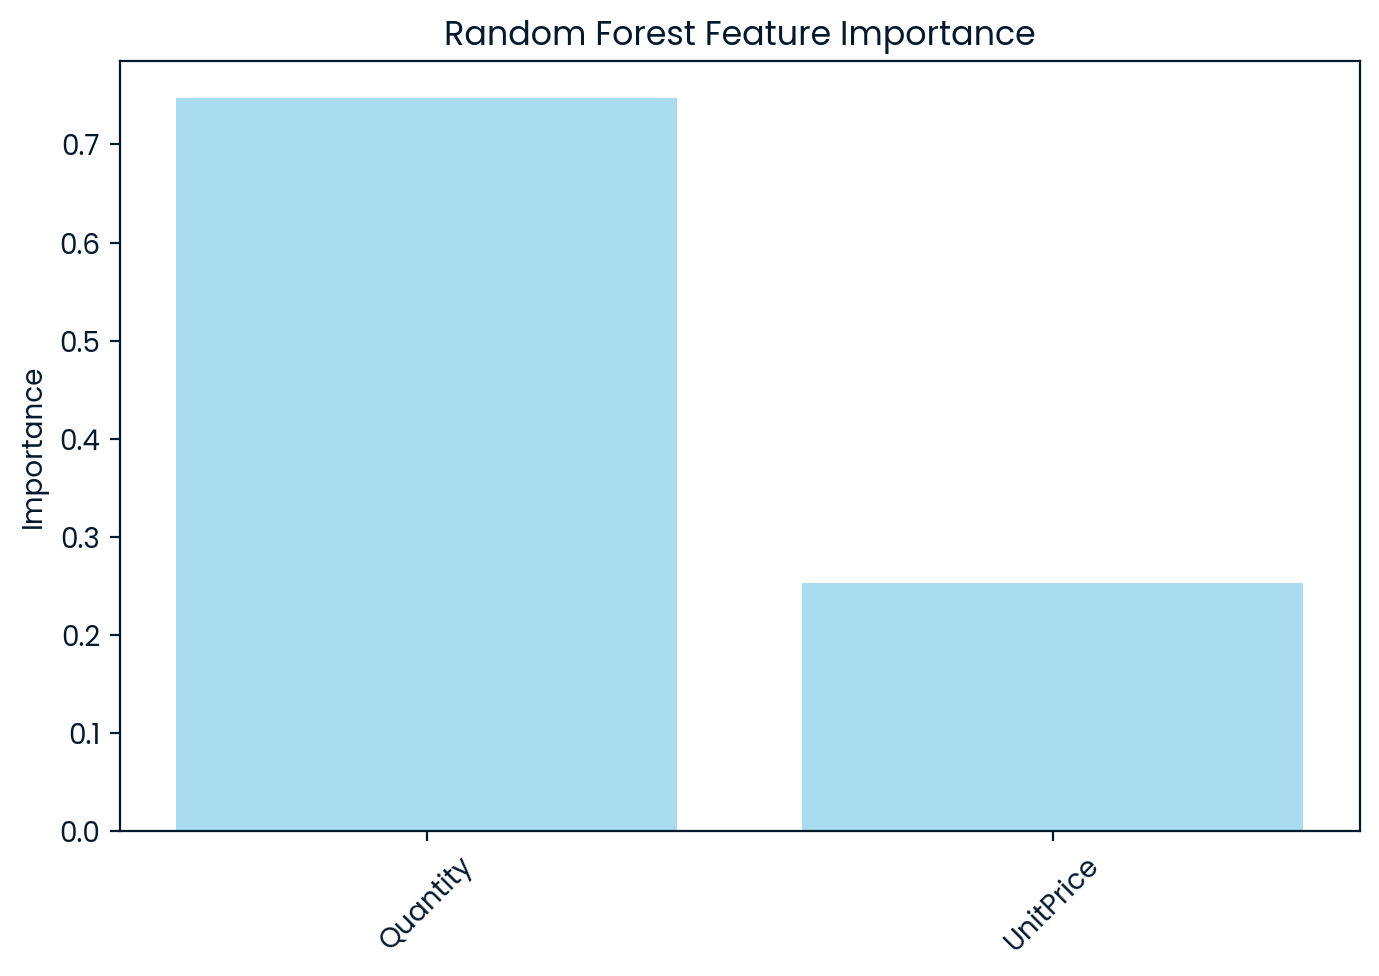

In [46]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

print("Feature Importances:", importance)

feature_names = features.columns  # or new_column_names if you renamed

plt.figure(figsize=(8,5))
plt.bar(feature_names, importance, color='skyblue', alpha=0.7)
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45)
plt.show()


# Results
The R squared of the Linear Regression, and the Random Forest Regression model is 0.84 and 0.53, meaning the Linear Regression model fits the features better. The RMSE of the Linear Regression, and the Random Forest Regression model is 224 and 391, meaning the Linear Regression model has less error in predicting values.

# Evaluate by Business Criteria
While Linear Regression has a higher R² (0.84 vs 0.53) and lower RMSE (224 vs 391), indicating more accurate predictions overall, using a ±15% range as a business KPI shows that Random Forest predictions fall within this range 99.53% of the time, compared to only 11.82% for Linear Regression. However, this is because the 15% threshold is very wide relative to Linear Regression’s more precise but sometimes slightly off predictions. Therefore, for actual planning and forecasting, Linear Regression is still the better model, as it captures revenue variations more accurately, even if fewer predictions fall within a loose tolerance range.

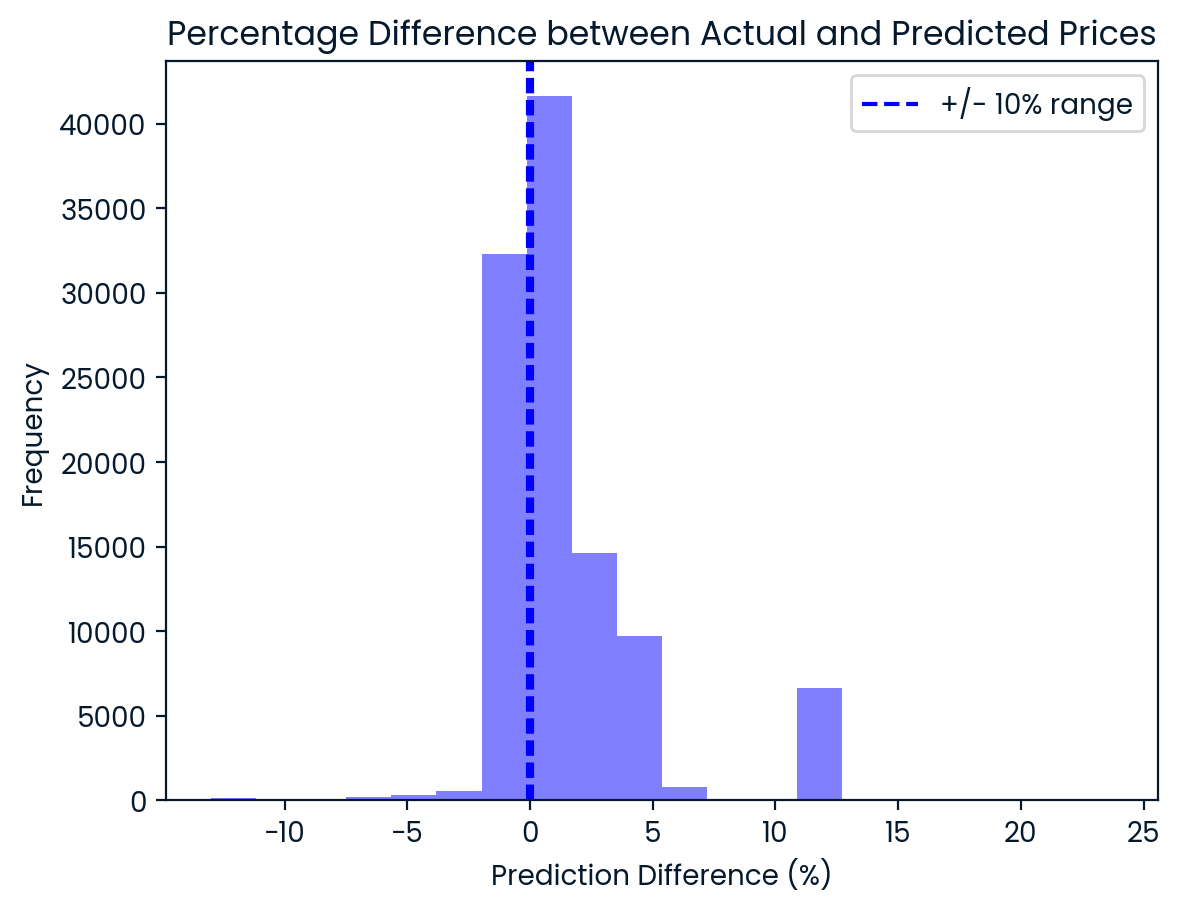

In [60]:
lr = lr[lr['UnitPrice'] != 0]

lr['Diff'] = (lr['TotalPrice'] - lr['UnitPrice']) / lr['UnitPrice']

lr = lr.replace([np.inf, -np.inf], np.nan).dropna()

plt.hist(lr['Diff'], bins=20, color='blue', alpha=0.5)
plt.axvline(x=0.1, color='b', linestyle='--', label='+/- 10% range')
plt.axvline(x=-0.1, color='b', linestyle='--')
plt.xlabel('Prediction Difference (%)')
plt.ylabel('Frequency')
plt.title('Percentage Difference between Actual and Predicted Prices')
plt.legend()
plt.show()


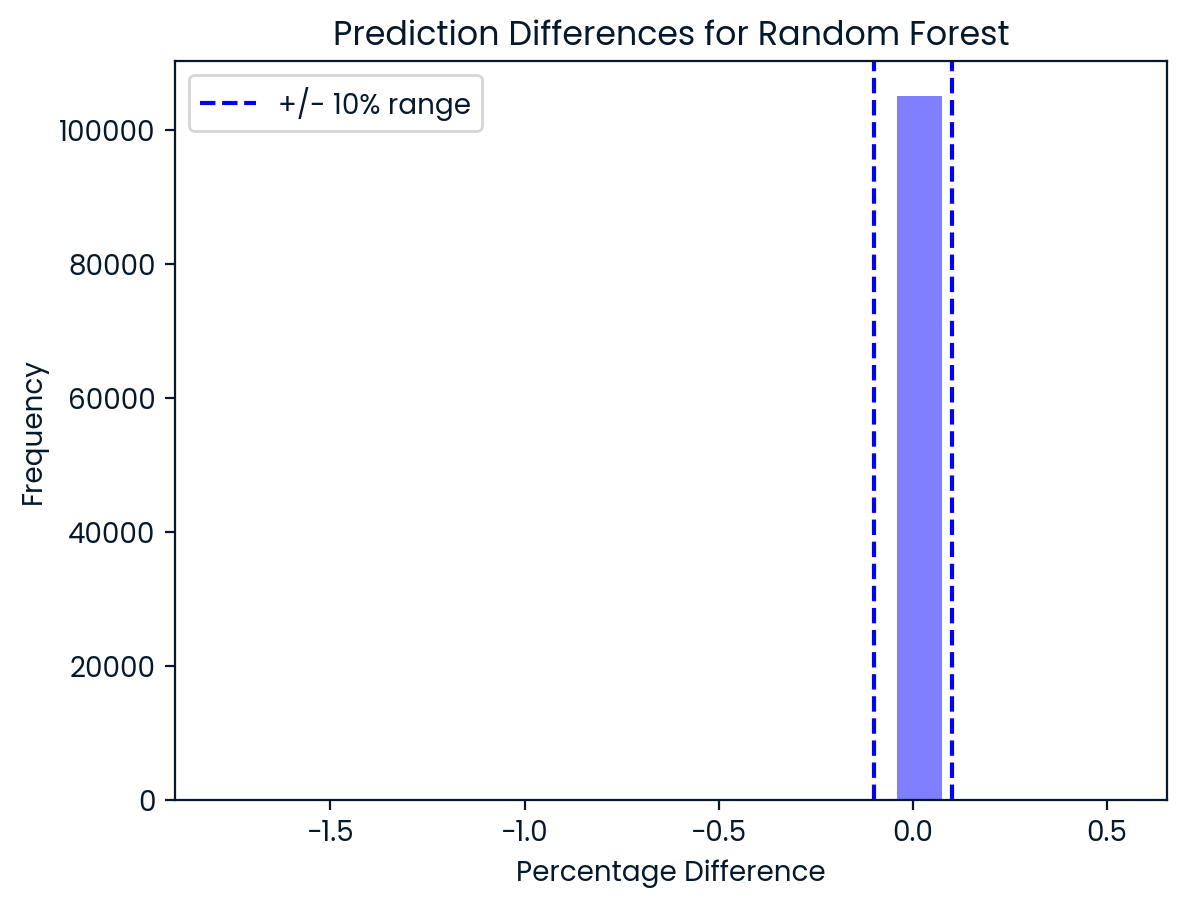

In [94]:
rf_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf,
    'UnitPrice': X_test['UnitPrice'], 
    'Quantity': X_test['Quantity']
})

rf_results = rf_results[rf_results['UnitPrice'] > 0]
rf_results['Diff'] = (rf_results['Predicted'] - rf_results['Actual']) / rf_results['Actual']
rf_results = rf_results[np.isfinite(rf_results['Diff'])]

plt.hist(rf_results['Diff'], bins=20, color='blue', alpha=0.5)
plt.axvline(x=0.1, color='b', linestyle='--', label='+/- 10% range')
plt.axvline(x=-0.1, color='b', linestyle='--')
plt.xlabel('Percentage Difference')
plt.ylabel('Frequency')
plt.title('Prediction Differences for Random Forest')
plt.legend()
plt.show()


In [97]:
# Avoid division by zero
y_test_safe = y_test.replace(0, 1)  # replace zero to avoid division error

# Linear Regression
within_15pct_lr = np.mean(np.abs(y_pred_lr - y_test_safe) / y_test_safe <= 0.15) * 100

# Random Forest
within_15pct_rf = np.mean(np.abs(y_pred_rf - y_test_safe) / y_test_safe <= 0.15) * 100

print(f"Linear Regression: {within_15pct_lr:.2f}% of predictions within ±15% of actual revenue")
print(f"Random Forest: {within_15pct_rf:.2f}% of predictions within ±15% of actual revenue")


Linear Regression: 11.82% of predictions within ±15% of actual revenue
Random Forest: 99.53% of predictions within ±15% of actual revenue


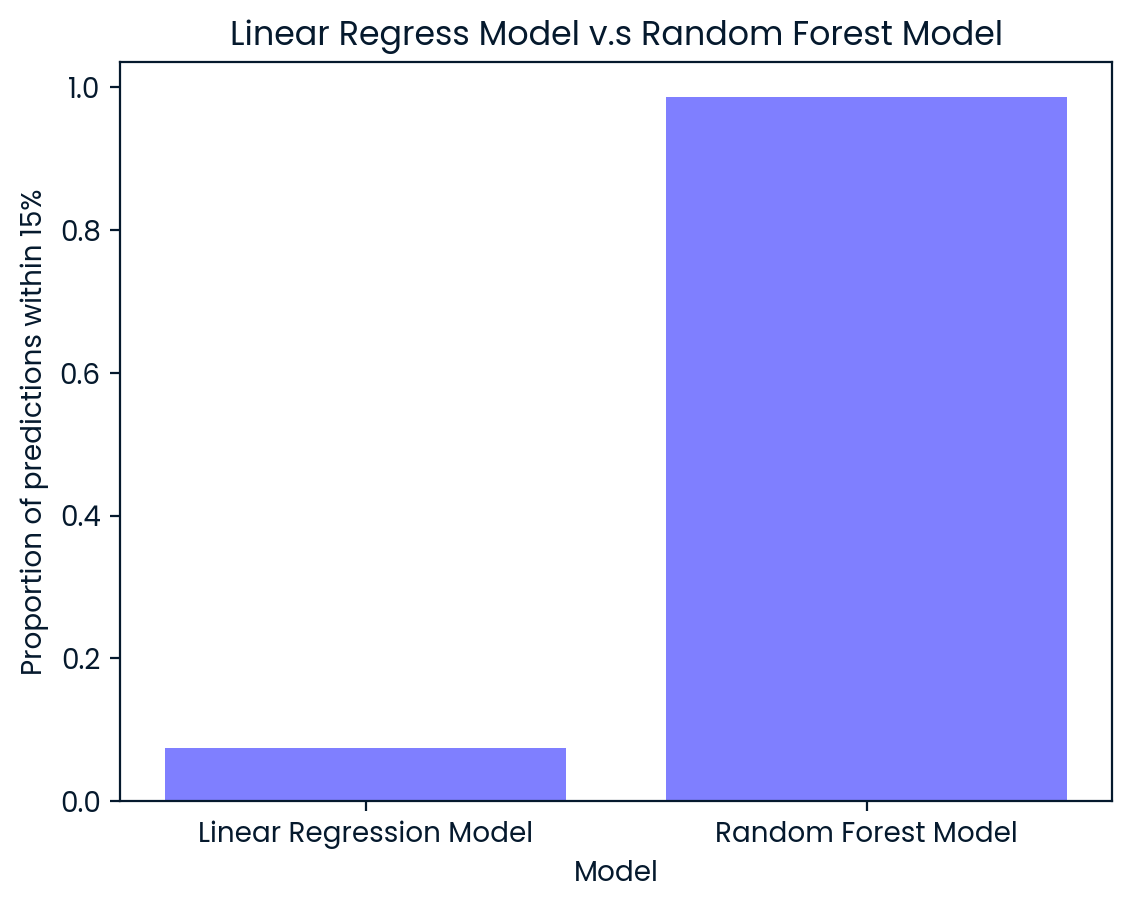

In [98]:
da = [pct_lr,pct_rf]
labels =['Linear Regression Model','Random Forest Model']
plt.bar(labels, da,color='blue', alpha=0.5)

plt.title('Linear Regress Model v.s Random Forest Model')
plt.xlabel('Model')
plt.ylabel('Proportion of predictions within 15%')

plt.show()

# Recommendation
To better understand customer purchasing behavior and predict transaction revenue, we recommend deploying the Linear Regression model into production. With R² = 0.84 and RMSE = 224, this model provides accurate forecasts, allowing the business owner to make informed decisions on inventory, pricing, and promotions. By predicting expected sales, the owner can optimize stock levels, focus marketing efforts on high-value customers, and reduce the risk of overstock or stockouts.
To ensure successful deployment and continuous improvement:
- Test the model on recent sales data to compare predictions with actual revenue.
- Identify and correct errors to improve accuracy.
- Deploy the model via a web dashboard or API so it can support operational decisions in real time.
- Continuously improve the model by adding new sales data, creating additional features, and fine-tuning parameters to capture evolving customer behaviors.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation